Basic Scikit-learn usage

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Load data
iris = load_iris()
X, y = iris.data, iris.target

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a decision tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print(f"Decision Tree accuracy: {dt.score(X_test, y_test):.3f}")

# Fit logistic regression—same 3 lines, different algorithm
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_train, y_train)
print(f"Logistic Regression accuracy: {lr.score(X_test, y_test):.3f}")

Decision Tree accuracy: 1.000
Logistic Regression accuracy: 1.000


Supervised vs Unsupervised

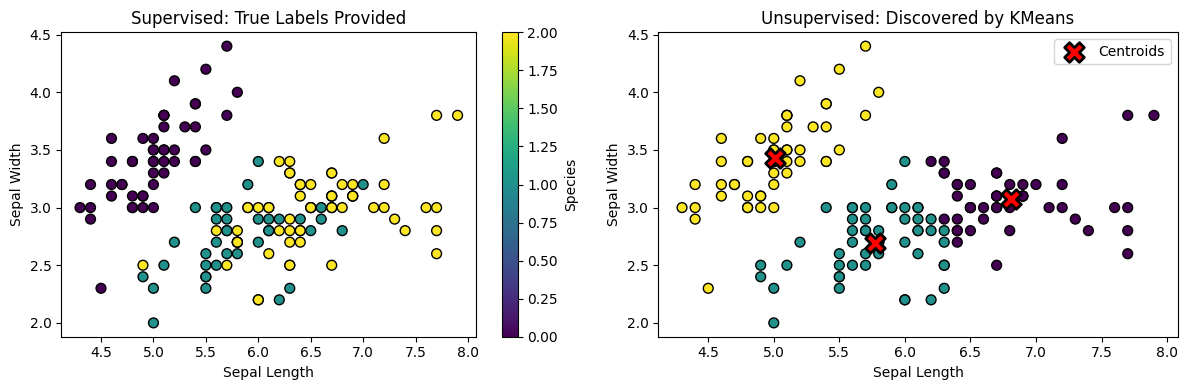

In [3]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# Use first two iris features for 2D plot
X_2d = iris.data[:, [0, 1]]
y_true = iris.target

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Supervised: plot with true labels
scatter1 = ax1.scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap='viridis', edgecolors='k', s=50)
ax1.set_title('Supervised: True Labels Provided')
ax1.set_xlabel('Sepal Length')
ax1.set_ylabel('Sepal Width')
plt.colorbar(scatter1, ax=ax1, label='Species')

# Unsupervised: KMeans discovers clusters without labels
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_2d)
scatter2 = ax2.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap='viridis', edgecolors='k', s=50)
ax2.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', marker='X', s=200, edgecolors='black', linewidth=2, label='Centroids')
ax2.set_title('Unsupervised: Discovered by KMeans')
ax2.set_xlabel('Sepal Length')
ax2.set_ylabel('Sepal Width')
ax2.legend()

plt.tight_layout()
plt.show()

Train vs Test Score

In [5]:
from sklearn.tree import DecisionTreeClassifier

# Fit on training data
dt = DecisionTreeClassifier(random_state=42,ccp_alpha=0.0)
dt.fit(X_train, y_train)

# Score on SAME training data (inflated)
train_score = dt.score(X_train, y_train)
# Score on DIFFERENT test data (honest)
test_score = dt.score(X_test, y_test)

print(f"Train score (overly optimistic): {train_score:.3f}")
print(f"Test score (honest estimate):    {test_score:.3f}")
print(f"Overfitting gap: {train_score - test_score:.3f}")

Train score (overly optimistic): 1.000
Test score (honest estimate):    1.000
Overfitting gap: 0.000


Estimator Types—Same API, Different Tasks

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

print("=== CLASSIFICATION ===")
clf = RandomForestClassifier(n_estimators=10, random_state=42)
clf.fit(X_train, y_train)
print(f"RandomForest accuracy: {clf.score(X_test, y_test):.3f}")

print("\n=== REGRESSION ===")
# Create a simple regression task: predict sepal length from other features
X_reg = iris.data[:, 1:]  # Use features 2-4
y_reg = iris.data[:, 0]   # Predict feature 1
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg = LinearRegression()
reg.fit(X_train_r, y_train_r)
print(f"LinearRegression R² score: {reg.score(X_test_r, y_test_r):.3f}")

print("\n=== CLUSTERING ===")
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_2d)
print(f"KMeans inertia: {kmeans.inertia_:.1f}")  # Lower = tighter clusters
print(f"Predicted clusters: {kmeans.predict(X_2d[:5])}")

=== CLASSIFICATION ===
RandomForest accuracy: 1.000

=== REGRESSION ===
LinearRegression R² score: 0.852

=== CLUSTERING ===
KMeans inertia: 37.1
Predicted clusters: [2 2 2 2 2]
